# 06: Sensitivity And Limitations

The goal is to stress-test the causal conclusions before writing the final project memo.

The previous notebooks built a coherent causal story through raw rank-position patterns, IPW adjustment, doubly robust estimation, heterogeneous effects, and policy simulation. This notebook asks the uncomfortable but necessary question below.

> How robust are these results to modeling choices, overlap assumptions, treatment definitions, and unobserved risks?

This is the notebook that makes the project more credible. It shows that we understand the assumptions behind the estimates and keep claims disciplined from observational logged data.

<!-- dataset-experiment-context -->
## Dataset and Design Context

This project uses the Microsoft News Dataset (MIND) impression logs. The working table is an impression-item panel: each row is one news item displayed inside a user impression slate.

The data come from a real observational ranking log. Top-3 exposure was created by a production ranker, so assignment must be treated as confounded. The treatment is top-3 exposure, the outcome is click-through, and the main causal risk is that the production ranker likely used relevance, freshness, and intent signals that remain only partly observed in the public data.

The project should therefore be read as an offline causal measurement and experiment-prioritization workflow. Naive rank-position click differences are descriptive. Adjusted estimates, overlap checks, heterogeneous effects, and policy simulations are used to decide what would be credible enough to test online.

**Role of this notebook.** This notebook stress-tests overlap, weight caps, feature sets, treatment definitions, and remaining limitations so the project keeps its claims aligned with what MIND can support.

<!-- mathematical-setup -->

## Mathematical Setup

Sensitivity analysis asks whether the estimated top-rank effect survives reasonable changes in design choices. If \(\widehat\tau(m)\) is the estimate under modeling choice \(m\), the notebook compares the range

$$
\left\{\widehat\tau(m):m\in\mathcal{M}\right\}
$$

across feature sets, treatment definitions, and overlap restrictions. Balance is summarized with standardized mean differences,

$$
\operatorname{SMD}(X_j)=
\frac{\bar X_{j,1}-\bar X_{j,0}}{\sqrt{(s_{j,1}^2+s_{j,0}^2)/2}},
$$

computed before and after adjustment. Large movement across specifications changes the strength of the claim that can be made from the observational ranking logs.


### What Can Go Wrong?

A causal estimate from logged recommendation data can fail for several reasons:

- **Poor overlap**: some rows are almost always top-ranked or almost always lower-ranked, leaving weak comparisons.
- **Extreme IPW weights**: a few rows can dominate weighted estimates.
- **Feature-set dependence**: results may change depending on which covariates are included.
- **Treatment-definition dependence**: `top 1`, `top 3`, and `top 10` are different interventions.
- **Unobserved confounding**: missing ranker scores, user intent, or freshness signals may bias estimates.
- **Metric limitation**: clicks capture short-term engagement and leave long-term satisfaction unresolved.

The purpose of this notebook is to measure obvious sensitivities, document limitations, and identify what would be needed for stronger evidence. The purpose is to measure obvious sensitivities, document limitations, and identify what would be needed for stronger evidence.

#### Setup

This cell imports the libraries used in the sensitivity analysis. We use pandas and numpy for data work, seaborn and matplotlib for plots, and scikit-learn for the nuisance models used in the doubly robust estimator.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)


This cell prepares the notebook environment for robustness, sensitivity checks, and limitations. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


#### Load The Processed Dataset

This cell loads the processed impression-level MIND-small table. Each row is a displayed item inside an impression. The same processed file has been used throughout the project, so sensitivity results are directly comparable with earlier notebooks.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
df = pd.read_parquet(DATA_PATH)

df.shape


(737762, 20)

The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


#### Modeling Sample

Sensitivity analysis reruns models many times. To keep the notebook interactive, we use a fixed random sample smaller than the full processed table. The goal is to see whether the estimate is stable under reasonable changes while keeping the notebook interactive.

#### Create Treatment Columns And Modeling Features

This cell creates a reusable modeling table. We keep the original `is_top_3` treatment and also define `is_top_10` for treatment-definition sensitivity. `is_top_1` already exists in the processed table. `log_item_exposures` is a non-click popularity proxy used in the richer feature sets.

In [3]:
MODEL_SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

model_df = (
    df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)

model_df["is_top_10"] = (model_df["rank_position"] <= 10).astype(int)
model_df["outcome"] = model_df["clicked"].astype(int)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])

pd.Series(
    {
        "rows": len(model_df),
        "click_rate": model_df["outcome"].mean(),
        "top_1_rate": model_df["is_top_1"].mean(),
        "top_3_rate": model_df["is_top_3"].mean(),
        "top_10_rate": model_df["is_top_10"].mean(),
    }
)


rows          100000.0000
click_rate         0.0396
top_1_rate         0.0269
top_3_rate         0.0802
top_10_rate        0.2359
dtype: float64

This cell defines the working analysis sample and standardizes treatment/outcome columns. Fixing this sample early keeps later model comparisons fair because each estimator works on the same rows and target definition.


#### Reusable Estimation Helpers

The sensitivity checks repeatedly estimate the same causal quantity under different settings. To avoid copying long model-fitting code several times, this section defines helper functions for preprocessing, AIPW estimation, IPW estimation, and confidence intervals.

#### Build Model Pipeline Helpers

This cell defines functions for creating sklearn pipelines. Numeric features are imputed and standardized. Categorical features are imputed and one-hot encoded. The code handles feature sets with or without categorical variables, which is useful for feature-set sensitivity.

In [4]:
# Build model pipeline helpers.
def make_preprocessor(numeric_cols, categorical_cols):
    """
    Build the shared preprocessing transformer for causal nuisance models.
    
    Idea
    ----
    Numeric columns are imputed and scaled when appropriate, while categorical columns are imputed and one-hot encoded so downstream propensity and outcome models receive a consistent design matrix.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.compose.ColumnTransformer
        Configured preprocessing transformer for the specified numeric and categorical columns.
    """
    transformers = []
    if numeric_cols:
        numeric_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )
        transformers.append(("num", numeric_pipeline, numeric_cols))

    if categorical_cols:
        categorical_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="infrequent_if_exist",
                        min_frequency=50,
                        sparse_output=True,
                    ),
                ),
            ]
        )
        transformers.append(("cat", categorical_pipeline, categorical_cols))

    return ColumnTransformer(transformers=transformers)


def make_logistic_pipeline(numeric_cols, categorical_cols):
    """
    Build a logistic-regression propensity pipeline.
    
    Idea
    ----
    The pipeline combines project-specific preprocessing with a logistic model so top-rank exposure or treatment assignment can be estimated from observed covariates.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline that preprocesses covariates and fits a logistic treatment model.
    """
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols)),
            (
                "model",
                LogisticRegression(
                    max_iter=500,
                    solver="lbfgs",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


This cell creates reusable modeling machinery for later estimates. The value is consistency. The same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


#### Define AIPW And IPW Estimation Helpers

This cell defines the main estimation functions. `estimate_aipw` cross-fits propensity and outcome models, computes per-row AIPW scores, and returns both the scored data and a summary table. `estimate_ipw_lift` estimates the IPW-adjusted lift from already-computed propensity scores and allows optional weight capping.

In [5]:
# Define AIPW and IPW estimation helpers.
def weighted_mean(values, weights):
    """
    Compute a weighted mean for causal diagnostics.
    
    Idea
    ----
    Use this helper when treated-control averages, covariate summaries, or estimator components need to respect inverse-propensity or stabilized weights.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted average after aligning values and weights and ignoring missing pairs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(values * weights) / np.sum(weights)


def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.sum(weights**2)


def estimate_ipw_lift(scored_df, eps=0.01, cap_quantile=None):
    """
    Estimate treatment lift with inverse-propensity weights.
    
    Idea
    ----
    The function caps or stabilizes weights when requested, then compares weighted treated and control outcome means to audit the rank-position effect.
    
    Parameters
    ----------
    scored_df : object
        Data frame containing outcomes, treatments, propensities, and scores.
    eps : object
        Small positive value used to avoid division by zero.
    cap_quantile : object
        Quantile used to cap large weights.
    
    Returns
    -------
    dict
        IPW estimate and diagnostics such as weight limits or effective sample size.
    """
    e = scored_df["e_hat"].clip(eps, 1 - eps).to_numpy()
    treatment = scored_df["treatment"].to_numpy()
    outcome = scored_df["outcome"].to_numpy()
    weights = np.where(treatment == 1, 1 / e, 1 / (1 - e))

    if cap_quantile is not None:
        weights = np.clip(weights, None, np.quantile(weights, cap_quantile))

    treated = treatment == 1
    control = ~treated
    treated_mean = weighted_mean(outcome[treated], weights[treated])
    control_mean = weighted_mean(outcome[control], weights[control])

    return {
        "ipw_treated_ctr": treated_mean,
        "ipw_control_ctr": control_mean,
        "ipw_lift": treated_mean - control_mean,
        "max_weight": weights.max(),
        "effective_sample_size": effective_sample_size(weights),
    }


def estimate_aipw(data, treatment_col, numeric_features, categorical_features, n_folds=2, eps=0.01):
    """
    Estimate a doubly robust treatment effect with cross-fitting.
    
    Idea
    ----
    The function fits propensity and outcome nuisance models on held-out folds, combines them into AIPW scores, and returns an effect estimate with uncertainty diagnostics.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    treatment_col : object
        Column indicating treatment or exposure status.
    numeric_features : object
        Numeric feature columns used by the model.
    categorical_features : object
        Categorical feature columns used by the model.
    n_folds : object
        Number of cross-fitting folds.
    eps : object
        Small positive value used to avoid division by zero.
    
    Returns
    -------
    dict
        AIPW estimate, interval components, and nuisance-model diagnostics.
    """
    work = data.copy().reset_index(drop=True)
    work["treatment"] = work[treatment_col].astype(int)
    work["outcome"] = work["clicked"].astype(int)

    propensity_features = numeric_features + categorical_features
    outcome_numeric_features = numeric_features + ["treatment"]
    outcome_features = outcome_numeric_features + categorical_features

    base_propensity_model = make_logistic_pipeline(numeric_features, categorical_features)
    base_outcome_model = make_logistic_pipeline(outcome_numeric_features, categorical_features)

    e_hat = np.zeros(len(work))
    mu1_hat = np.zeros(len(work))
    mu0_hat = np.zeros(len(work))
    propensity_metrics = []
    outcome_metrics = []

    splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(work[propensity_features], work["treatment"]), start=1):
        train_df = work.iloc[train_idx]
        valid_df = work.iloc[valid_idx]

        propensity_model = clone(base_propensity_model)
        propensity_model.fit(train_df[propensity_features], train_df["treatment"])
        e_valid = propensity_model.predict_proba(valid_df[propensity_features])[:, 1]
        e_hat[valid_idx] = e_valid

        outcome_model = clone(base_outcome_model)
        outcome_model.fit(train_df[outcome_features], train_df["outcome"])

        valid_actual = valid_df[outcome_features]
        y_valid_hat = outcome_model.predict_proba(valid_actual)[:, 1]

        valid_treated = valid_df[propensity_features].copy()
        valid_treated["treatment"] = 1
        valid_treated = valid_treated[outcome_features]

        valid_control = valid_df[propensity_features].copy()
        valid_control["treatment"] = 0
        valid_control = valid_control[outcome_features]

        mu1_hat[valid_idx] = outcome_model.predict_proba(valid_treated)[:, 1]
        mu0_hat[valid_idx] = outcome_model.predict_proba(valid_control)[:, 1]

        propensity_metrics.append(
            {
                "fold": fold,
                "roc_auc": roc_auc_score(valid_df["treatment"], e_valid),
                "average_precision": average_precision_score(valid_df["treatment"], e_valid),
                "brier_score": brier_score_loss(valid_df["treatment"], e_valid),
            }
        )
        outcome_metrics.append(
            {
                "fold": fold,
                "roc_auc": roc_auc_score(valid_df["outcome"], y_valid_hat),
                "average_precision": average_precision_score(valid_df["outcome"], y_valid_hat),
                "brier_score": brier_score_loss(valid_df["outcome"], y_valid_hat),
            }
        )

    work["e_hat"] = e_hat
    work["mu1_hat"] = mu1_hat
    work["mu0_hat"] = mu0_hat
    work["mu_diff_hat"] = work["mu1_hat"] - work["mu0_hat"]

    e = work["e_hat"].clip(eps, 1 - eps).to_numpy()
    treatment = work["treatment"].to_numpy()
    outcome = work["outcome"].to_numpy()
    mu1 = work["mu1_hat"].to_numpy()
    mu0 = work["mu0_hat"].to_numpy()

    work["aipw_score"] = (mu1 - mu0) + treatment * (outcome - mu1) / e - (1 - treatment) * (outcome - mu0) / (1 - e)

    naive_treated = work.loc[work["treatment"] == 1, "outcome"].mean()
    naive_control = work.loc[work["treatment"] == 0, "outcome"].mean()
    dr_ate = work["aipw_score"].mean()
    dr_se = work["aipw_score"].std(ddof=1) / np.sqrt(len(work))
    ipw = estimate_ipw_lift(work, eps=eps, cap_quantile=0.99)

    summary = {
        "treatment_col": treatment_col,
        "rows": len(work),
        "treatment_rate": work["treatment"].mean(),
        "naive_lift": naive_treated - naive_control,
        "ipw_lift_99cap": ipw["ipw_lift"],
        "outcome_regression_lift": work["mu_diff_hat"].mean(),
        "dr_lift": dr_ate,
        "standard_error": dr_se,
        "ci_95_lower": dr_ate - 1.96 * dr_se,
        "ci_95_upper": dr_ate + 1.96 * dr_se,
        "propensity_auc_mean": pd.DataFrame(propensity_metrics)["roc_auc"].mean(),
        "outcome_auc_mean": pd.DataFrame(outcome_metrics)["roc_auc"].mean(),
    }

    return work, summary, pd.DataFrame(propensity_metrics), pd.DataFrame(outcome_metrics)


This cell creates reusable modeling machinery for later estimates. The value is consistency. The same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


### Baseline Estimate

Before running sensitivity checks, we create one baseline estimate for the main treatment: `is_top_3`. This uses the richer feature set from earlier notebooks and 2-fold cross-fitting to keep repeated sensitivity runs manageable.

#### Define The Baseline Feature Set

This cell defines the baseline covariates. The feature set includes user history, slate size, text-length proxies, time context, item exposure, category, and subcategory. This is the main adjustment set used in later sensitivity comparisons.

In [6]:
full_numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
full_categorical_features = ["category", "subcategory"]

full_numeric_features, full_categorical_features


(['history_len',
  'candidate_set_size',
  'title_length',
  'abstract_length',
  'hour',
  'day_of_week',
  'log_item_exposures'],
 ['category', 'subcategory'])

The feature-set sensitivity checks whether the estimated lift depends heavily on one adjustment specification. Robustness across feature sets gives more confidence than a result that only appears under one model.


#### Estimate The Baseline Top-3 Effect

This cell runs the baseline doubly robust estimator. It returns the scored dataset with nuisance predictions and AIPW scores, plus a summary table with naive, IPW, outcome-regression, and doubly robust estimates.

In [7]:
baseline_scored, baseline_summary, baseline_propensity_metrics, baseline_outcome_metrics = estimate_aipw(
    model_df,
    treatment_col="is_top_3",
    numeric_features=full_numeric_features,
    categorical_features=full_categorical_features,
    n_folds=2,
    eps=0.01,
)

pd.DataFrame([baseline_summary])


,treatment_col,rows,treatment_rate,naive_lift,ipw_lift_99cap,outcome_regression_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper,propensity_auc_mean,outcome_auc_mean
0,is_top_3,100000,0.0802,0.0660,0.0180,0.0276,0.0121,0.0034,0.0054,0.0188,0.7701,0.6992


The baseline estimate is the reference point for all sensitivity checks. Later cells vary overlap, weights, features, and treatment definitions to see whether this estimate is robust. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Inspect Baseline Nuisance Model Metrics

This cell shows cross-fitted model metrics for the baseline propensity and outcome models. These metrics are diagnostics: they tell us whether the nuisance models have signal, but the causal estimate still depends on causal assumptions.

In [8]:
display(baseline_propensity_metrics)
display(baseline_outcome_metrics)


,fold,roc_auc,average_precision,brier_score
0,1,0.7719,0.3259,0.0664
1,2,0.7683,0.3271,0.0664


,fold,roc_auc,average_precision,brier_score
0,1,0.6994,0.1081,0.0365
1,2,0.6990,0.1151,0.0372


The nuisance-model metrics show how well the supporting prediction models perform. Weak nuisance models can make IPW, DR, and policy estimates less reliable, so these diagnostics help judge the stability of the causal workflow.


### Overlap Sensitivity

Overlap means that comparable rows have some chance of being treated and some chance of being control. If estimated propensities are too close to 0 or 1, causal estimates rely on weak comparisons.

This section trims rows outside increasingly strict propensity ranges and recomputes the doubly robust estimate on the remaining population. The estimand changes as we trim: stricter thresholds estimate the effect for better-overlap rows only.

#### Recompute DR Lift Under Overlap Trimming

This cell filters rows to several propensity ranges such as `[0.05, 0.95]` and `[0.10, 0.90]`. For each range, it reports how many rows remain, the treatment rate among retained rows, and the DR lift using the retained AIPW scores.

In [9]:
overlap_rows = []
for lower, upper in [(0.01, 0.99), (0.05, 0.95), (0.10, 0.90), (0.15, 0.85)]:
    kept = baseline_scored.query("@lower <= e_hat <= @upper")
    scores = kept["aipw_score"]
    se = scores.std(ddof=1) / np.sqrt(len(scores))
    overlap_rows.append(
        {
            "propensity_range": f"[{lower:.2f}, {upper:.2f}]",
            "rows_kept": len(kept),
            "share_kept": len(kept) / len(baseline_scored),
            "treatment_rate_kept": kept["treatment"].mean(),
            "dr_lift": scores.mean(),
            "standard_error": se,
            "ci_95_lower": scores.mean() - 1.96 * se,
            "ci_95_upper": scores.mean() + 1.96 * se,
        }
    )

overlap_sensitivity = pd.DataFrame(overlap_rows)
overlap_sensitivity


,propensity_range,rows_kept,share_kept,treatment_rate_kept,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,"[0.01, 0.99]",85484,0.8548,0.0907,0.0125,0.0028,0.0070,0.0181
1,"[0.05, 0.95]",53286,0.5329,0.1264,0.0269,0.0029,0.0212,0.0325
2,"[0.10, 0.90]",32670,0.3267,0.1709,0.0391,0.0039,0.0316,0.0467
3,"[0.15, 0.85]",18368,0.1837,0.2324,0.0575,0.0057,0.0463,0.0687


The overlap sensitivity results show how the estimate changes when low-overlap rows are removed. Stability here supports the claim that the effect is robust to hard-to-compare observations.


#### Plot Overlap Sensitivity

This cell plots the DR lift under each trimming rule. If estimates are stable as overlap becomes stricter, that supports robustness. If estimates change sharply, the result may be driven by low-overlap observations.

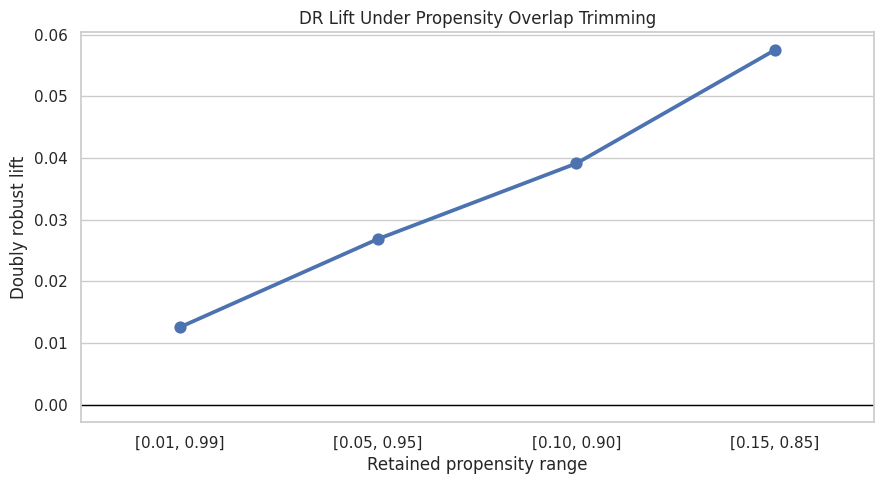

In [10]:
plt.figure(figsize=(9, 5))
sns.pointplot(data=overlap_sensitivity, x="propensity_range", y="dr_lift")
plt.axhline(0, color="black", linewidth=1)
plt.title("DR Lift Under Propensity Overlap Trimming")
plt.xlabel("Retained propensity range")
plt.ylabel("Doubly robust lift")
plt.tight_layout()


The overlap sensitivity results show how the estimate changes when low-overlap rows are removed. Stability here supports the claim that the effect is robust to hard-to-compare observations.


### Weight Sensitivity

IPW estimates can be unstable when some rows receive very large weights. Earlier notebooks used capped weights. Here we compare several cap choices to see whether IPW lift depends heavily on extreme weights.

#### Compare IPW Weight Caps

This cell recomputes IPW lift with no weight cap and with caps at the 99.5th, 99th, and 95th percentiles. It also reports effective sample size. If tighter caps move the estimate dramatically, IPW is fragile.

In [11]:
weight_rows = []
for label, cap in [("no_cap", None), ("cap_99_5", 0.995), ("cap_99", 0.99), ("cap_95", 0.95)]:
    result = estimate_ipw_lift(baseline_scored, eps=0.01, cap_quantile=cap)
    weight_rows.append({"weight_rule": label, **result})

weight_sensitivity = pd.DataFrame(weight_rows)
weight_sensitivity


,weight_rule,ipw_treated_ctr,ipw_control_ctr,ipw_lift,max_weight,effective_sample_size
0,no_cap,0.0429,0.0360,0.0069,100.0000,8549.2487
1,cap_99_5,0.0463,0.0360,0.0103,56.4496,13201.5961
2,cap_99,0.0540,0.0360,0.0180,26.7517,23108.0017
3,cap_95,0.0875,0.0360,0.0515,5.0305,66230.5762


The weight calculation translates propensity scores into reweighting factors for the observed data. Stabilization and clipping protect the estimate from a few extreme-propensity rows dominating the result.


#### Plot Weight Sensitivity

This cell plots IPW lift under different weight caps. Stable estimates across cap choices are reassuring. Large swings suggest the weighted estimate depends on a small number of high-weight observations.

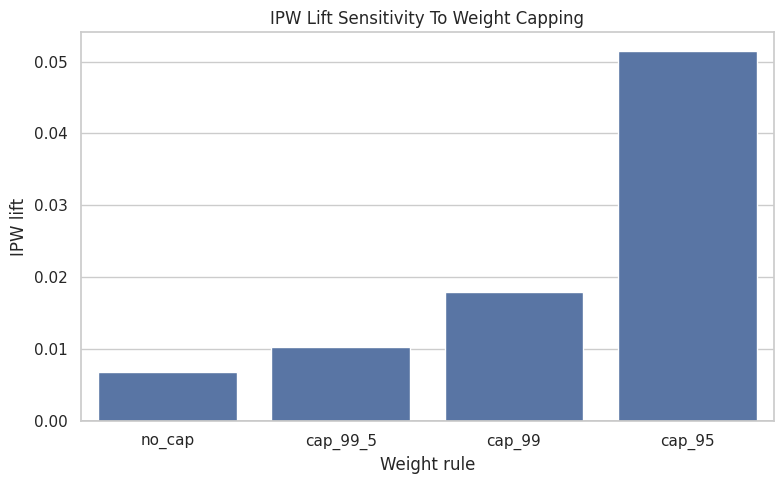

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=weight_sensitivity, x="weight_rule", y="ipw_lift")
plt.axhline(0, color="black", linewidth=1)
plt.title("IPW Lift Sensitivity To Weight Capping")
plt.xlabel("Weight rule")
plt.ylabel("IPW lift")
plt.tight_layout()


The weight-cap sensitivity checks whether extreme inverse-probability weights control the estimate. If the estimate is stable across caps, the result is less dependent on a few influential rows.


### Feature-Set Sensitivity

Causal adjustment depends on which observed covariates enter the nuisance models. If the estimate changes dramatically when we add reasonable features, the conclusion is model-dependent. If it remains directionally similar, the result is more credible.

#### Estimate Top-3 Lift Under Multiple Feature Sets

This cell compares three adjustment sets: simple context features, content/category features, and the fuller baseline feature set. The full feature-set result reuses the baseline estimate so we avoid unnecessary refitting.

In [13]:
# Estimate top-3 lift under multiple feature sets.
feature_configs = {
    "simple_context": {
        "numeric": ["history_len", "candidate_set_size", "hour", "day_of_week"],
        "categorical": [],
    },
    "content_category": {
        "numeric": ["history_len", "candidate_set_size", "title_length", "abstract_length", "hour", "day_of_week"],
        "categorical": ["category"],
    },
    "full_context_content_exposure": {
        "numeric": full_numeric_features,
        "categorical": full_categorical_features,
    },
}

feature_sensitivity_rows = []
for feature_set, config in feature_configs.items():
    if feature_set == "full_context_content_exposure":
        summary = baseline_summary.copy()
    else:
        _, summary, _, _ = estimate_aipw(
            model_df,
            treatment_col="is_top_3",
            numeric_features=config["numeric"],
            categorical_features=config["categorical"],
            n_folds=2,
            eps=0.01,
        )
    summary["feature_set"] = feature_set
    feature_sensitivity_rows.append(summary)

feature_sensitivity = pd.DataFrame(feature_sensitivity_rows)
feature_sensitivity[
    [
        "feature_set",
        "naive_lift",
        "ipw_lift_99cap",
        "outcome_regression_lift",
        "dr_lift",
        "ci_95_lower",
        "ci_95_upper",
        "propensity_auc_mean",
        "outcome_auc_mean",
    ]
]


,feature_set,naive_lift,ipw_lift_99cap,outcome_regression_lift,dr_lift,ci_95_lower,ci_95_upper,propensity_auc_mean,outcome_auc_mean
0,simple_context,0.0660,0.0198,0.0299,0.0120,0.0057,0.0184,0.7768,0.6938
1,content_category,0.0660,0.0190,0.0289,0.0121,0.0056,0.0185,0.7750,0.6955
2,full_context_content_exposure,0.0660,0.0180,0.0276,0.0121,0.0054,0.0188,0.7701,0.6992


The feature-set sensitivity checks whether the estimated lift depends heavily on one adjustment specification. Robustness across feature sets gives more confidence than a result that only appears under one model.


#### Plot Feature-Set Sensitivity

This cell plots the doubly robust estimate across feature sets. Similar values suggest the result is less likely to be an artifact of one adjustment set. Meaningful differences tell us which covariates materially affect the causal estimate.

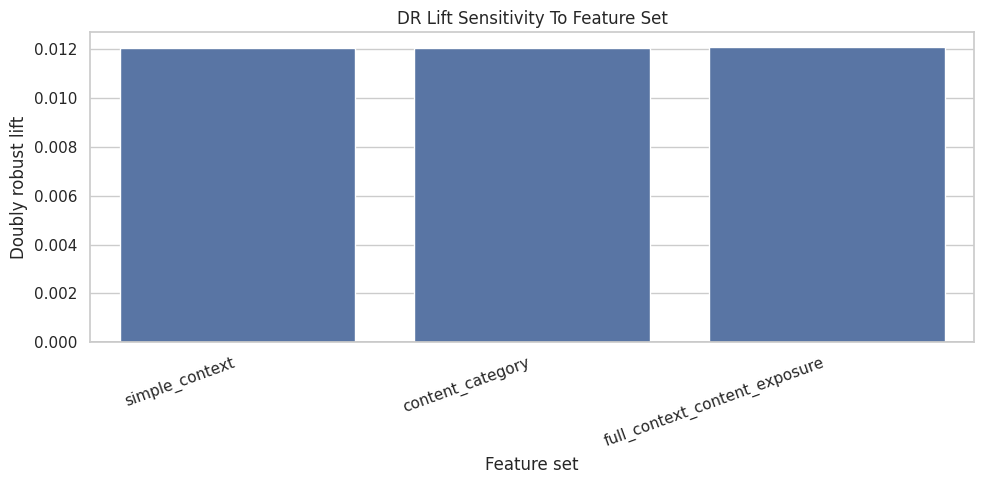

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_sensitivity, x="feature_set", y="dr_lift")
plt.axhline(0, color="black", linewidth=1)
plt.title("DR Lift Sensitivity To Feature Set")
plt.xlabel("Feature set")
plt.ylabel("Doubly robust lift")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()


This output is part of the robustness, sensitivity checks, and limitations workflow. Read it as a checkpoint: it either verifies an input, defines reusable analysis machinery, or produces a diagnostic that motivates the next step in the notebook.


### Treatment-Definition Sensitivity

The phrase “ranking position effect” can mean different interventions. Moving an item to rank 1, moving it into the top 3, and moving it into the top 10 are different interventions. This section compares related treatment definitions.

#### Estimate Effects For Top-1, Top-3, And Top-10 Exposure

This cell reruns the doubly robust estimator for three treatment definitions. These estimates describe different interventions because each treatment has a different control group and different product meaning. The comparison shows whether the rank effect is concentrated at the very top or persists through broader high-visibility positions.

In [15]:
# Estimate effects for top-1, top-3, and top-10 exposure.
treatment_labels = {
    "is_top_1": "rank 1 vs lower",
    "is_top_3": "rank 1-3 vs lower",
    "is_top_10": "rank 1-10 vs lower",
}

treatment_sensitivity_rows = []
for treatment_col, treatment_label in treatment_labels.items():
    if treatment_col == "is_top_3":
        summary = baseline_summary.copy()
    else:
        _, summary, _, _ = estimate_aipw(
            model_df,
            treatment_col=treatment_col,
            numeric_features=full_numeric_features,
            categorical_features=full_categorical_features,
            n_folds=2,
            eps=0.01,
        )
    summary["treatment_definition"] = treatment_label
    treatment_sensitivity_rows.append(summary)

treatment_sensitivity = pd.DataFrame(treatment_sensitivity_rows)
treatment_sensitivity[
    [
        "treatment_definition",
        "treatment_rate",
        "naive_lift",
        "ipw_lift_99cap",
        "outcome_regression_lift",
        "dr_lift",
        "ci_95_lower",
        "ci_95_upper",
    ]
]


,treatment_definition,treatment_rate,naive_lift,ipw_lift_99cap,outcome_regression_lift,dr_lift,ci_95_lower,ci_95_upper
0,rank 1 vs lower,0.0269,0.0757,0.0390,0.0304,0.0120,0.0049,0.0191
1,rank 1-3 vs lower,0.0802,0.0660,0.0180,0.0276,0.0121,0.0054,0.0188
2,rank 1-10 vs lower,0.2359,0.0419,0.0097,0.0137,0.0111,0.0060,0.0162


The treatment-definition sensitivity asks whether the story changes when exposure is defined more narrowly or broadly. This helps clarify whether the finding is about top rank specifically or general high-rank visibility.


#### Plot Treatment-Definition Sensitivity

This cell plots the DR lift for the three treatment definitions. A larger top-1 effect than top-10 effect would suggest visibility is most valuable at the very top. A similar effect across definitions would suggest broader high-rank exposure matters.

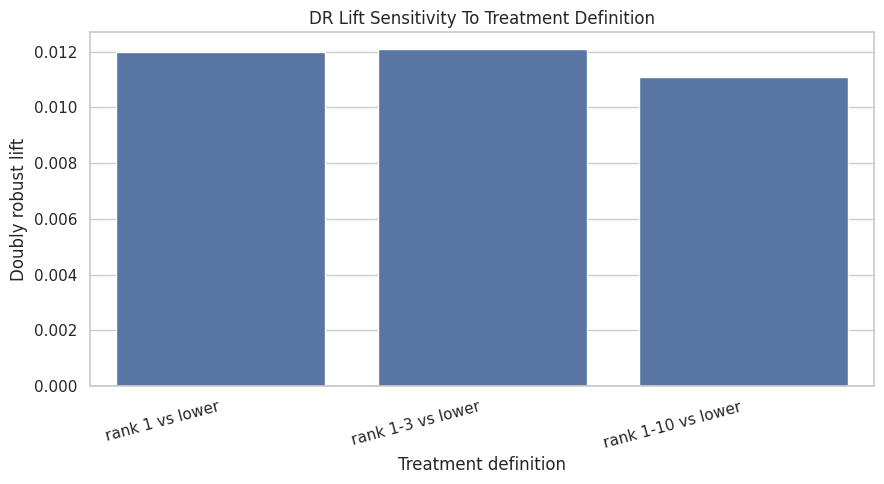

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(data=treatment_sensitivity, x="treatment_definition", y="dr_lift")
plt.axhline(0, color="black", linewidth=1)
plt.title("DR Lift Sensitivity To Treatment Definition")
plt.xlabel("Treatment definition")
plt.ylabel("Doubly robust lift")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()


The treatment-definition sensitivity asks whether the story changes when exposure is defined more narrowly or broadly. This helps clarify whether the finding is about top rank specifically or general high-rank visibility.


### Pre-Adjustment Imbalance Check

This is a control-style diagnostic. If treatment is strongly associated with pre-treatment covariates, then naive comparisons have weak credibility. This check reinforces why causal adjustment was necessary.

#### Compute Standardized Mean Differences Before Adjustment

This cell computes standardized mean differences for numeric covariates comparing top-3 rows with lower-ranked rows before weighting. Large absolute values show imbalance between treatment and control groups.

In [17]:
# Compute standardized mean differences before adjustment.
def standardized_mean_difference(data, feature, treatment_col="is_top_3"):
    """
    Compute a standardized mean difference for one covariate.
    
    Idea
    ----
    The helper compares treated and control covariate means, optionally under weights, to diagnose observed imbalance in the causal design.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    feature : object
        Name of the covariate or feature to summarize.
    treatment_col : object
        Column indicating treatment or exposure status.
    
    Returns
    -------
    float
        Standardized mean difference for the requested column.
    """
    treated = data[treatment_col] == 1
    control = ~treated
    mean_t = data.loc[treated, feature].mean()
    mean_c = data.loc[control, feature].mean()
    var_t = data.loc[treated, feature].var(ddof=0)
    var_c = data.loc[control, feature].var(ddof=0)
    pooled_sd = np.sqrt((var_t + var_c) / 2)
    return (mean_t - mean_c) / pooled_sd if pooled_sd > 0 else np.nan


imbalance = pd.DataFrame(
    {
        "feature": full_numeric_features,
        "smd_before_adjustment": [standardized_mean_difference(model_df, feature) for feature in full_numeric_features],
    }
)
imbalance["abs_smd"] = imbalance["smd_before_adjustment"].abs()
imbalance.sort_values("abs_smd", ascending=False)


,feature,smd_before_adjustment,abs_smd
1,candidate_set_size,-0.9319,0.9319
6,log_item_exposures,0.3435,0.3435
0,history_len,-0.0641,0.0641
5,day_of_week,-0.0385,0.0385
2,title_length,0.0335,0.0335
4,hour,0.0130,0.0130
3,abstract_length,-0.0127,0.0127


The imbalance output documents the confounding problem before adjustment. This is useful in the limitations story because it shows why causal methods are needed and where unobserved confounding may still remain.


#### Plot Pre-Adjustment Imbalance

This cell visualizes covariate imbalance before adjustment. The dashed line at 0.1 is a common rough threshold. Features above that threshold differ meaningfully between top-3 and lower-ranked rows.

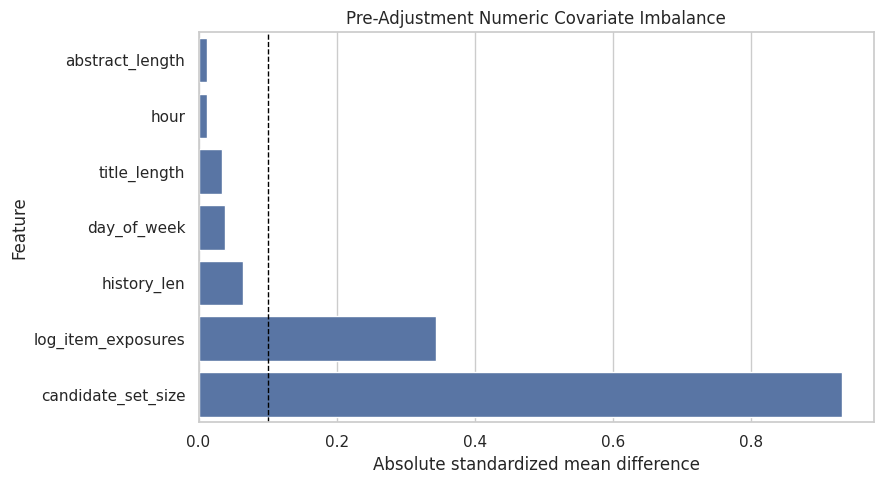

In [18]:
plt.figure(figsize=(9, 5))
sns.barplot(data=imbalance.sort_values("abs_smd", ascending=True), x="abs_smd", y="feature")
plt.axvline(0.1, color="black", linestyle="--", linewidth=1)
plt.title("Pre-Adjustment Numeric Covariate Imbalance")
plt.xlabel("Absolute standardized mean difference")
plt.ylabel("Feature")
plt.tight_layout()


The imbalance output documents the confounding problem before adjustment. This is useful in the limitations story because it shows why causal methods are needed and where unobserved confounding may still remain.


### Robustness Summary

This section gathers the main sensitivity results into compact tables. The goal is to make the final memo easier to write: which checks were reassuring, and which checks exposed fragility?

#### Combine Key Sensitivity Results

This cell creates a compact summary of baseline, feature-set, and treatment-definition sensitivity. It gives one place to compare the main estimates alongside the detailed tables above.

In [19]:
robustness_summary = pd.concat(
    [
        pd.DataFrame([baseline_summary]).assign(check="baseline", variant="top_3_full_features"),
        feature_sensitivity.rename(columns={"feature_set": "variant"}).assign(check="feature_set"),
        treatment_sensitivity.rename(columns={"treatment_definition": "variant"}).assign(check="treatment_definition"),
    ],
    ignore_index=True,
)

robustness_summary[["check", "variant", "treatment_rate", "naive_lift", "ipw_lift_99cap", "dr_lift", "ci_95_lower", "ci_95_upper"]]


,check,variant,treatment_rate,naive_lift,ipw_lift_99cap,dr_lift,ci_95_lower,ci_95_upper
0,baseline,top_3_full_features,0.0802,0.0660,0.0180,0.0121,0.0054,0.0188
1,feature_set,simple_context,0.0802,0.0660,0.0198,0.0120,0.0057,0.0184
2,feature_set,content_category,0.0802,0.0660,0.0190,0.0121,0.0056,0.0185
3,feature_set,full_context_content_exposure,0.0802,0.0660,0.0180,0.0121,0.0054,0.0188
4,treatment_definition,rank 1 vs lower,0.0269,0.0757,0.0390,0.0120,0.0049,0.0191
5,treatment_definition,rank 1-3 vs lower,0.0802,0.0660,0.0180,0.0121,0.0054,0.0188
6,treatment_definition,rank 1-10 vs lower,0.2359,0.0419,0.0097,0.0111,0.0060,0.0162


The robustness summary gathers the main sensitivity checks into one table. This makes it easier to state which conclusions are stable and which require caution. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


### Limitations Table

The limitations table states the boundaries of the evidence directly. It translates technical risks into product implications and next steps.

#### Create A Final Limitations Table

This cell creates a memo-ready limitations table. Each row describes a risk, why it matters, what this project did to reduce it, and what would improve the evidence in a real product setting.

In [20]:
# Create a final limitations table.
limitations = pd.DataFrame(
    [
        {
            "risk": "Unobserved confounding",
            "why_it_matters": "The logged ranker may use relevance scores, freshness signals, or user intent features that are missing from this public dataset.",
            "what_we_did": "Adjusted for observed user history, slate size, content metadata, time, and item exposure proxies.",
            "what_would_improve_it": "Use production ranker scores, richer user/item features, or randomized ranking experiments.",
        },
        {
            "risk": "Limited overlap",
            "why_it_matters": "Some items may be almost deterministically top-ranked or lower-ranked, making counterfactual comparisons weak.",
            "what_we_did": "Inspected propensity overlap and recomputed estimates under trimming thresholds.",
            "what_would_improve_it": "Restrict claims to common-support regions or collect randomized exploration traffic.",
        },
        {
            "risk": "Extreme weights",
            "why_it_matters": "A few high-weight observations can dominate IPW estimates.",
            "what_we_did": "Compared IPW estimates under several weight caps and reported effective sample size.",
            "what_would_improve_it": "Use stabilized weights, overlap weighting, or stronger propensity models with calibration checks.",
        },
        {
            "risk": "Treatment definition ambiguity",
            "why_it_matters": "Top-1, top-3, and top-10 exposure correspond to different product interventions.",
            "what_we_did": "Estimated effects under multiple treatment definitions.",
            "what_would_improve_it": "Tie the treatment definition to a concrete UI or ranking-policy change.",
        },
        {
            "risk": "Clicks are short-term",
            "why_it_matters": "A click may not indicate satisfaction, watch time, retention, or long-term member value.",
            "what_we_did": "Used clicks because they are the available MIND outcome.",
            "what_would_improve_it": "Use downstream satisfaction, dwell time, retention, or long-term engagement metrics.",
        },
        {
            "risk": "Interference across items",
            "why_it_matters": "Promoting one item changes exposure for other items in the same slate.",
            "what_we_did": "Framed policy simulation as prioritization under limited counterfactual support.",
            "what_would_improve_it": "Evaluate full-slate policies with online experiments or slate-aware causal methods.",
        },
    ]
)

limitations


,risk,why_it_matters,what_we_did,what_would_improve_it
0,Unobserved confounding,"The logged ranker may use relevance scores, fr...","Adjusted for observed user history, slate size...","Use production ranker scores, richer user/item..."
1,Limited overlap,Some items may be almost deterministically top...,Inspected propensity overlap and recomputed es...,Restrict claims to common-support regions or c...
2,Extreme weights,A few high-weight observations can dominate IP...,Compared IPW estimates under several weight ca...,"Use stabilized weights, overlap weighting, or ..."
3,Treatment definition ambiguity,"Top-1, top-3, and top-10 exposure correspond t...",Estimated effects under multiple treatment def...,Tie the treatment definition to a concrete UI ...
4,Clicks are short-term,"A click may not indicate satisfaction, watch t...",Used clicks because they are the available MIN...,"Use downstream satisfaction, dwell time, reten..."
5,Interference across items,Promoting one item changes exposure for other ...,Framed policy simulation as prioritization und...,Evaluate full-slate policies with online exper...


This cell saves reusable report artifacts. Figures, tables, limitations, and summary text make the analysis easier to audit outside the notebook itself. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


## Final Takeaways

Across multiple adjustment strategies, top-ranked exposure remains associated with higher click probability, but the strength of that claim depends on measured confounding, overlap, weight stability, treatment definition, and model specification.

The sensitivity checks define the boundary of the evidence. Stable signs across specifications support the ranking-effect hypothesis. Changes in magnitude warn against treating the estimate as a universal production constant. The result should motivate targeted online experiments for top-3 placement.
